# 🌾 Sugarcane Yield Prediction: Ensemble Methods, Bias-Variance Tradeoff & Regularization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)
![Python 3.10+](https://img.shields.io/badge/Python-3.10%2B-blue.svg)
![Scikit-Learn](https://img.shields.io/badge/Library-Scikit--Learn-orange.svg)
![XGBoost](https://img.shields.io/badge/Ensemble-XGBoost-red.svg)
![LightGBM](https://img.shields.io/badge/Ensemble-LightGBM-brightgreen.svg)

---

## 📌 Executive Overview & Educational Objectives
This notebook provides an in-depth, hands-on, and theoretically rigorous study of advanced machine learning techniques applied to **Sugarcane Yield Prediction** (both continuous yield estimation in tons/ha and binary High vs. Low Yield classification).

### 🎯 Key Learning Objectives for Students:
1. **Ensemble Methods Architecture**:
   - **Bagging (Bootstrap Aggregating)**: Variance reduction via bootstrap sampling, Random Forests, and Out-of-Bag (OOB) validation.
   - **Boosting**: Sequential residual reduction, Gradient Boosting, **XGBoost (Extreme Gradient Boosting)**, and **LightGBM (Light Gradient Boosting Machine)**.
2. **Bias–Variance Trade-off**:
   - Mathematical decomposition of Expected Mean Squared Error ($\text{MSE} = \text{Bias}^2 + \text{Variance} + \sigma^2$).
   - Understanding model capacity, underfitting (high bias) vs overfitting (high variance), and identifying the optimal complexity sweet spot.
3. **Overfitting and Underfitting**:
   - Causes, diagnostic metrics (train vs test divergence, generalization gap), learning curves, and validation curves.
   - Practical prevention strategies: cross-validation, regularization, tree pruning, early stopping, and ensemble aggregation.
4. **Regularization ($L_1$ and $L_2$)**:
   - Mathematical formulations of $L_1$ (Lasso: sparsity & feature selection) and $L_2$ (Ridge: weight shrinkage).
   - Regularization within tree boosting: XGBoost `reg_alpha` ($L_1$) and `reg_lambda` ($L_2$), LightGBM penalties, and tree complexity constraints.
5. **Comprehensive Benchmarking & Deployment**:
   - Full comparative evaluation across Linear, Regularized, Bagging, and Boosting models.
   - Feature importance interpretability and model export to pickle (`.pkl`) for real-time agricultural inference.


In [1]:
# Google Colab Setup (Uncomment if executing in Colab)
# !pip install -q xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn

import os
import sys
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
# Scikit-Learn Model Selection & Evaluation
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, StratifiedKFold,
    learning_curve, validation_curve
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Scikit-Learn Preprocessing & Pipelines
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Linear & Baseline Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

# Ensemble Models
from sklearn.ensemble import (
    BaggingRegressor, BaggingClassifier,
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)

# Gradient Boosted Decision Tree Libraries
import xgboost as xgb
import lightgbm as lgb

# Plotting Configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 110

print("✅ All required libraries imported successfully!")
print(f"   - Scikit-Learn version: {sklearn.__version__}")
print(f"   - XGBoost version:      {xgb.__version__}")
print(f"   - LightGBM version:     {lgb.__version__}")


✅ All required libraries imported successfully!
   - Scikit-Learn version: 1.8.0
   - XGBoost version:      3.3.0
   - LightGBM version:     4.7.0


---
## 1. 📚 Theoretical Foundations & Conceptual Framework

Before writing code, let us establish the mathematical and conceptual foundations behind the **Bias-Variance Tradeoff**, **Overfitting/Underfitting**, **Regularization**, and **Ensemble Methods**.

### 1.1 The Bias–Variance Decomposition

For any regression problem where true relationship is $y = f(x) + \epsilon$ with zero-mean noise $\mathbb{E}[\epsilon] = 0$ and variance $\text{Var}(\epsilon) = \sigma^2$, let $\hat{f}(x)$ be an estimate trained on dataset $\mathcal{D}$. The expected generalization error (MSE) on an unseen test point $x$ decomposes into three orthogonal components:

$$\mathbb{E}\left[(y - \hat{f}(x))^2\right] = \underbrace{\left(\mathbb{E}[\hat{f}(x)] - f(x)\right)^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}\left[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\right]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible Error}}$$

| Component | Definition | Real-World Meaning in Agriculture |
| :--- | :--- | :--- |
| **Bias** | Error introduced by approximating a complex reality with an overly simple model. | Model assumes yield is strictly linear with water, ignoring heat stress saturation thresholds. (Underfitting) |
| **Variance** | Error from model sensitivity to small fluctuations/noise in training data. | Model memorizes specific soil readings from plot 42; fails on plot 43 with different moisture. (Overfitting) |
| **Irreducible Error ($\sigma^2$)** | Inherent noise in data, unmeasured latent variables, sensor tolerance. | Unexpected pest outbreaks, unrecorded cloud cover, localized microclimates. |

---

### 1.2 Overfitting vs. Underfitting: Diagnostic Guide

| Aspect | Underfitting (High Bias) | Good Fit (Optimal Tradeoff) | Overfitting (High Variance) |
| :--- | :--- | :--- | :--- |
| **Training Error** | High | Low | Extremely Low (near zero) |
| **Validation Error** | High | Low | High (diverges from train) |
| **Train vs. Test Gap** | Small gap (both poor) | Small gap (both strong) | **Large gap** ($R^2_{\text{train}} \gg R^2_{\text{test}}$) |
| **Model Complexity** | Overly simple (e.g. linear, shallow tree) | Balanced capacity | Overly complex (unpruned trees, high degrees) |
| **Primary Remedy** | Increase model capacity, engineer features, reduce regularization | Retain architecture, tune hyperparameters | Ensembling (Bagging), Regularization ($L_1/L_2$), Pruning, Early Stopping |

---

### 1.3 Regularization: $L_1$ (Lasso) vs. $L_2$ (Ridge)

Regularization penalizes model complexity by adding a penalty term to the empirical loss function:

$$J(w) = \mathcal{L}_{\text{data}}(w) + \lambda \cdot \Omega(w)$$

1. **$L_2$ Regularization (Ridge / Tikhonov)**:
   $$\Omega(w) = \|w\|_2^2 = \sum_{j=1}^p w_j^2$$
   - Shrinks coefficients continuously towards zero without setting them exactly to zero.
   - Smooth, differentiable circular/spherical contour. Ideal for handling multicollinearity (e.g., Rainfall + Irrigation + Total Water).

2. **$L_1$ Regularization (Lasso)**:
   $$\Omega(w) = \|w\|_1 = \sum_{j=1}^p |w_j|$$
   - Non-differentiable at vertices (diamond/octahedron contour), driving less important feature weights **strictly to zero**.
   - Acts as **automated feature selection**, producing sparse, highly interpretable models.

3. **Regularization in Tree Boosting (XGBoost & LightGBM)**:
   Tree boosting incorporates both $L_1$ (`reg_alpha`) and $L_2$ (`reg_lambda`) penalties on tree leaf weights $w$:
   $$\mathcal{L}_{\text{tree}} = \sum_{i=1}^n l(y_i, \hat{y}_i) + \sum_{m=1}^M \left[ \gamma T_m + \frac{1}{2}\lambda \sum_{j=1}^{T_m} w_{mj}^2 + \alpha \sum_{j=1}^{T_m} |w_{mj}| \right]$$
   - $\gamma$ penalizes the number of terminal leaves $T$.
   - $\lambda$ ($L_2$) shrinks leaf weights to prevent extreme predictions.
   - $\alpha$ ($L_1$) encourages sparsity in leaf weights.

---

### 1.4 Ensemble Paradigms: Bagging vs. Boosting

```
                    ┌─────────────────────────┐
                    │    ENSEMBLE METHODS     │
                    └────────────┬────────────┘
                ┌────────────────┴────────────────┐
                ▼                                 ▼
   ┌──────────────────────────┐      ┌──────────────────────────┐
   │ BAGGING (Parallel)       │      │ BOOSTING (Sequential)    │
   │ Reduce VARIANCE          │      │ Reduce BIAS              │
   ├──────────────────────────┤      ├──────────────────────────┤
   │ • Independent Bootstrap  │      │ • Adaptive Residuals     │
   │ • Deep, unpruned trees   │      │ • Shallow weak learners  │
   │ • Simple averaging/vote  │      │ • Weighted additive sum  │
   │ • Examples: Bagged Trees,│      │ • Examples: AdaBoost,    │
   │   Random Forest          │      │   GBM, XGBoost, LightGBM │
   └──────────────────────────┘      └──────────────────────────┘
```

#### Bagging vs. Boosting Comparison:

| Characteristic | Bagging (e.g., Random Forest) | Boosting (e.g., XGBoost, LightGBM) |
| :--- | :--- | :--- |
| **Learner Relationship** | Independent, parallel | Dependent, sequential (iterative residual correction) |
| **Base Estimator** | High-variance, low-bias (deep trees) | High-bias, low-variance (shallow trees / stumps) |
| **Primary Error Reduced** | **Variance** ($\text{Var}(\bar{X}) = \rho \sigma^2 + \frac{1-\rho}{M}\sigma^2$) | **Bias** ($f_M(x) = f_{M-1}(x) + \eta h_M(x)$) |
| **Aggregation Mechanism** | Simple average or majority voting | Weighted sum of stage-wise weak estimators |
| **Outlier Sensitivity** | Low (outliers diluted across bootstrap samples) | High (can overfit to noisy outliers if unregularized) |
| **Tuning Focus** | `n_estimators`, `max_features` | `learning_rate` ($\eta$), `max_depth`, `reg_lambda`, early stopping |

#### Why XGBoost and LightGBM are Industry Standards:
- **XGBoost**: Uses second-order Taylor expansion (gradients $g_i$ and hessians $h_i$), built-in $L_1/L_2$ regularization, cache-aware access, and sparsity-aware split finding.
- **LightGBM**: Uses **Histogram-based split finding**, **Leaf-wise (best-first) tree growth** with max depth limit, **Gradient-based One-Side Sampling (GOSS)**, and **Exclusive Feature Bundling (EFB)** for up to $10\times$ faster training and lower RAM footprint.


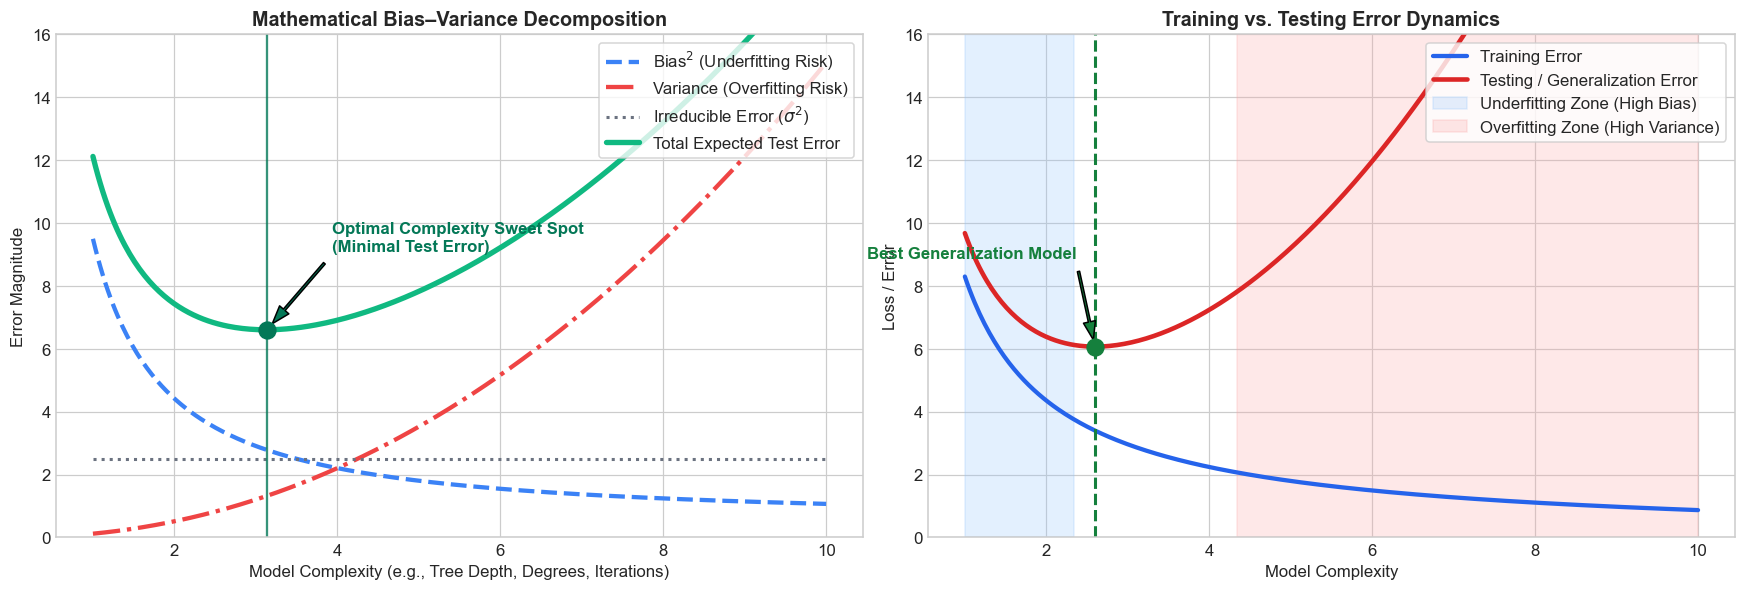

In [2]:
# -----------------------------------------------------------------------------
# VISUALIZING THE BIAS-VARIANCE TRADEOFF & MODEL COMPLEXITY
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Subplot 1: Mathematical Decomposition Curves
complexity = np.linspace(1, 10, 300)
bias_squared = 9.0 / (complexity**1.2) + 0.5
variance = 0.12 * (complexity**2.1)
irreducible_error = np.full_like(complexity, 2.5)
total_error = bias_squared + variance + irreducible_error

opt_idx = np.argmin(total_error)
opt_complexity = complexity[opt_idx]

axes[0].plot(complexity, bias_squared, label=r'Bias$^2$ (Underfitting Risk)', color='#3b82f6', lw=2.8, linestyle='--')
axes[0].plot(complexity, variance, label='Variance (Overfitting Risk)', color='#ef4444', lw=2.8, linestyle='-.')
axes[0].plot(complexity, irreducible_error, label=r'Irreducible Error ($\sigma^2$)', color='#6b7280', lw=2.0, linestyle=':')
axes[0].plot(complexity, total_error, label='Total Expected Test Error', color='#10b981', lw=3.5)

axes[0].axvline(opt_complexity, color='#047857', linestyle='-', lw=1.5, alpha=0.8)
axes[0].scatter([opt_complexity], [total_error[opt_idx]], color='#047857', s=120, zorder=5)
axes[0].annotate('Optimal Complexity Sweet Spot\n(Minimal Test Error)',
                 xy=(opt_complexity, total_error[opt_idx]),
                 xytext=(opt_complexity + 0.8, total_error[opt_idx] + 2.5),
                 arrowprops=dict(facecolor='#047857', shrink=0.08, width=1.5, headwidth=8),
                 fontweight='bold', color='#047857')

axes[0].set_title('Mathematical Bias–Variance Decomposition', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Model Complexity (e.g., Tree Depth, Degrees, Iterations)', fontsize=11)
axes[0].set_ylabel('Error Magnitude', fontsize=11)
axes[0].legend(loc='upper right', frameon=True)
axes[0].set_ylim(0, 16)

# Subplot 2: Train vs. Test Error Curve (Overfitting / Underfitting Zones)
train_error = 8.5 / (complexity**0.9) - 0.2
test_error = train_error + 0.18 * (complexity**2.2) + 1.2
test_opt_idx = np.argmin(test_error)

axes[1].plot(complexity, train_error, label='Training Error', color='#2563eb', lw=2.8)
axes[1].plot(complexity, test_error, label='Testing / Generalization Error', color='#dc2626', lw=3.0)

# Shaded Regions
axes[1].axvspan(1, opt_complexity - 0.8, color='#93c5fd', alpha=0.25, label='Underfitting Zone (High Bias)')
axes[1].axvspan(opt_complexity + 1.2, 10, color='#fca5a5', alpha=0.25, label='Overfitting Zone (High Variance)')

axes[1].axvline(complexity[test_opt_idx], color='#15803d', linestyle='--', lw=2)
axes[1].scatter([complexity[test_opt_idx]], [test_error[test_opt_idx]], color='#15803d', s=120, zorder=5)
axes[1].annotate('Best Generalization Model',
                 xy=(complexity[test_opt_idx], test_error[test_opt_idx]),
                 xytext=(complexity[test_opt_idx] - 2.8, test_error[test_opt_idx] + 2.8),
                 arrowprops=dict(facecolor='#15803d', shrink=0.08, width=1.5, headwidth=8),
                 fontweight='bold', color='#15803d')

axes[1].set_title('Training vs. Testing Error Dynamics', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Model Complexity', fontsize=11)
axes[1].set_ylabel('Loss / Error', fontsize=11)
axes[1].legend(loc='upper right', frameon=True)
axes[1].set_ylim(0, 16)

plt.tight_layout()
plt.show()


---
## 2. ⚙️ Dataset Loading & Agricultural Domain Preprocessing

The dataset models sugarcane crop production across distinct agricultural plots with soil, climate, and irrigation attributes:
- **`Soil_Type`**: Categorical soil variety (`Clayey`, `Loamy`, `Sandy`).
- **`Rainfall_mm`**: Seasonal precipitation in millimeters.
- **`Irrigation_liters_ha`**: Supplemental irrigation water provided.
- **`Fertilizer_kg_ha`**: Quantity of NPK fertilizer applied per hectare.
- **`Temperature_C`**: Average ambient temperature in Celsius.
- **`Water_Usage_liters_ha`**: Total water consumed by the sugarcane crop.
- **`Yield_tons_ha`**: Target variable for regression (measured sugarcane harvest).

### Feature Engineering:
1. **`Total_Water_ha`**: $\text{Rainfall\_mm} + \text{Irrigation\_liters\_ha}$
2. **`Water_Temp_Ratio`**: $\frac{\text{Total\_Water\_ha}}{\text{Temperature\_C} + 10^{-5}}$ (Hydrological stress index)
3. **`Fertilizer_Water_Ratio`**: $\frac{\text{Fertilizer\_kg\_ha}}{\text{Total\_Water\_ha} + 10^{-5}}$ (Nutrient dilution efficiency)
4. **`High_Yield_Class`**: Binary classification target: $1$ if yield $\ge \text{Median}$, else $0$.


In [3]:
# -----------------------------------------------------------------------------
# DATA LOADING, FEATURE ENGINEERING & PIPELINE PREPARATION
# -----------------------------------------------------------------------------
dataset_candidates = [
    "sugarcane_yield_dataset.csv",
    "Datasets/sugarcane_yield_dataset_large.csv",
    "datasets/sugarcane_yield_dataset_large.csv",
    "Datasets/sugarcane_yield_dataset.csv"
]

data_path = None
for candidate in dataset_candidates:
    if os.path.exists(candidate):
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError("Sugarcane dataset file not found in workspace!")

print(f"📂 Loading sugarcane dataset from: {data_path}")
df = pd.read_csv(data_path)
print(f"   Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Drop non-predictive ID column if present
if "Plot_ID" in df.columns:
    df = df.drop(columns=["Plot_ID"])

# Feature Engineering
df["Total_Water_ha"] = df["Rainfall_mm"] + df["Irrigation_liters_ha"]
df["Water_Temp_Ratio"] = df["Total_Water_ha"] / (df["Temperature_C"] + 1e-5)
df["Fertilizer_Water_Ratio"] = df["Fertilizer_kg_ha"] / (df["Total_Water_ha"] + 1e-5)

# Classification Target
yield_median = df["Yield_tons_ha"].median()
df["High_Yield_Class"] = (df["Yield_tons_ha"] >= yield_median).astype(int)

print(f"📊 Yield Summary: Min={df['Yield_tons_ha'].min():.1f}, Median={yield_median:.1f}, Max={df['Yield_tons_ha'].max():.1f} tons/ha")
print(f"   Class Distribution: High={sum(df['High_Yield_Class']==1)}, Low={sum(df['High_Yield_Class']==0)}")

# Define Feature Matrices & Targets
X = df.drop(columns=["Yield_tons_ha", "High_Yield_Class"])
y_reg = df["Yield_tons_ha"]
y_cls = df["High_Yield_Class"]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"   Numerical Features ({len(num_cols)}): {num_cols}")
print(f"   Categorical Features ({len(cat_cols)}): {cat_cols}")

# Unified Preprocessing Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)

# 80/20 Train/Test Splits
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.20, random_state=42
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cls, test_size=0.20, random_state=42, stratify=y_cls
)

print(f"✅ Preprocessing pipeline and train/test splits configured!")
print(f"   Train samples: {X_train_r.shape[0]} | Test samples: {X_test_r.shape[0]}")


📂 Loading sugarcane dataset from: sugarcane_yield_dataset.csv
   Shape: 1000 rows, 8 columns
📊 Yield Summary: Min=31.0, Median=63.5, Max=96.0 tons/ha
   Class Distribution: High=500, Low=500
   Numerical Features (8): ['Rainfall_mm', 'Irrigation_liters_ha', 'Fertilizer_kg_ha', 'Temperature_C', 'Water_Usage_liters_ha', 'Total_Water_ha', 'Water_Temp_Ratio', 'Fertilizer_Water_Ratio']
   Categorical Features (1): ['Soil_Type']
✅ Preprocessing pipeline and train/test splits configured!
   Train samples: 800 | Test samples: 200


---
## 3. 🌲 Bagging in Action: Bagging Regressor, Random Forest & Out-of-Bag (OOB)

### 3.1 The Mathematics of Bagging (Variance Reduction)
Suppose we generate $M$ bootstrap training sets $\mathcal{D}_1, \mathcal{D}_2, \dots, \mathcal{D}_M$ by sampling $N$ points with replacement. We train a high-variance base learner $\hat{f}_m(x)$ on each and aggregate predictions:

$$\hat{f}_{\text{bag}}(x) = \frac{1}{M} \sum_{m=1}^M \hat{f}_m(x)$$

If each tree has variance $\sigma^2$ and the pairwise correlation between trees is $\rho$:
$$\text{Var}\left(\hat{f}_{\text{bag}}(x)\right) = \rho \sigma^2 + \frac{1 - \rho}{M} \sigma^2$$

- As $M \to \infty$, the second term $\frac{1 - \rho}{M} \sigma^2 \to 0$.
- The remaining error is governed by $\rho \sigma^2$.
- **Why Random Forest Beats Simple Bagging**: Standard bagging trees are correlated ($\rho$ is moderately high) because strong predictors are chosen at the root of every tree. Random Forest introduces **random feature subsampling** (`max_features`), forcing trees to explore diverse splits and drastically reducing $\rho$!

### 3.2 Out-of-Bag (OOB) Validation
For a dataset of size $N$, the probability of a specific instance NOT being selected in a bootstrap sample of size $N$ is:
$$\lim_{N \to \infty} \left(1 - \frac{1}{N}\right)^N = e^{-1} \approx 0.368 \quad (36.8\%)$$
This means every tree has $\approx 36.8\%$ unseen **Out-of-Bag** samples. Evaluating each training point only on the subset of trees where it was out-of-bag yields an unbiased performance metric **without requiring a separate validation set**!


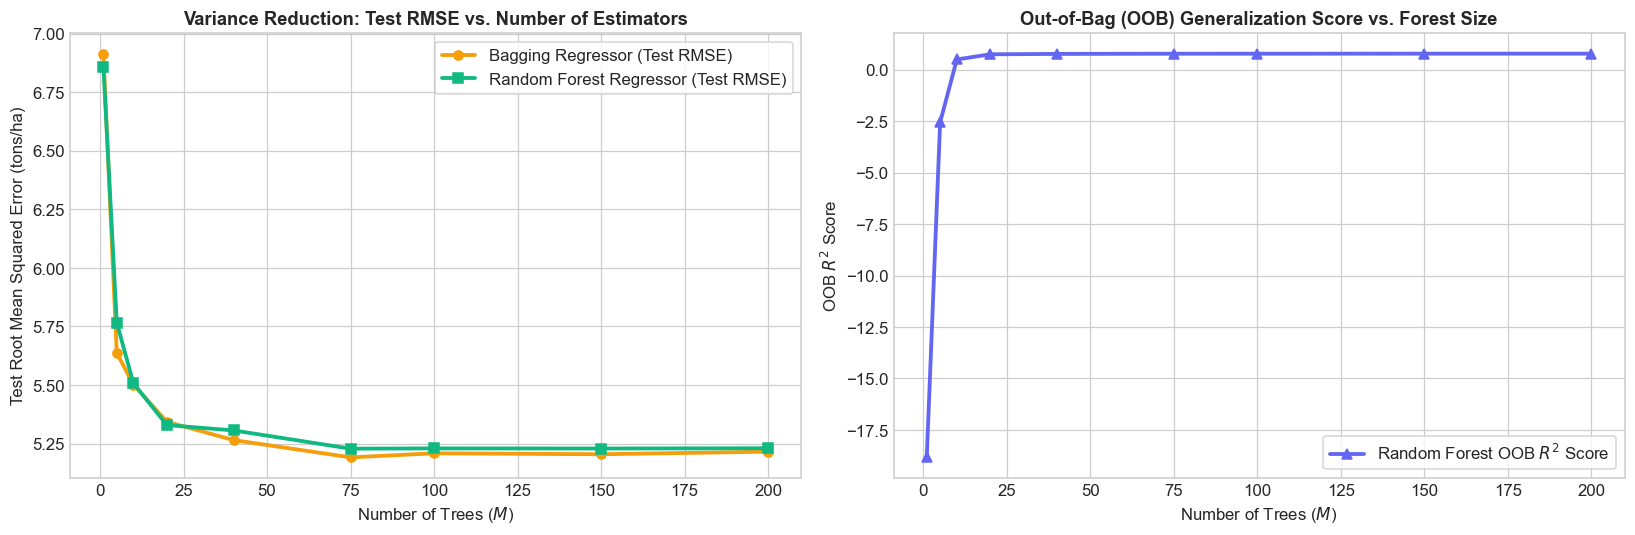

🏆 Final Random Forest Test RMSE (200 trees): 5.2298 tons/ha
📊 Final Random Forest OOB R2 Score:         0.7817


In [4]:
# -----------------------------------------------------------------------------
# BAGGING & RANDOM FOREST: VARIANCE REDUCTION ACROSS ENSEMBLE SIZE
# -----------------------------------------------------------------------------
estimator_counts = [1, 5, 10, 20, 40, 75, 100, 150, 200]
bagging_test_rmse = []
rf_test_rmse = []
rf_oob_r2 = []

for n_est in estimator_counts:
    # 1. Bagging Regressor (using unpruned Decision Trees)
    bag = Pipeline([
        ('prep', preprocessor),
        ('model', BaggingRegressor(
            estimator=DecisionTreeRegressor(max_depth=None, random_state=42),
            n_estimators=n_est,
            random_state=42
        ))
    ])
    bag.fit(X_train_r, y_train_r)
    bag_preds = bag.predict(X_test_r)
    bagging_test_rmse.append(np.sqrt(mean_squared_error(y_test_r, bag_preds)))
    
    # 2. Random Forest Regressor (with OOB score)
    rf = Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=n_est,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        ))
    ])
    rf.fit(X_train_r, y_train_r)
    rf_preds = rf.predict(X_test_r)
    rf_test_rmse.append(np.sqrt(mean_squared_error(y_test_r, rf_preds)))
    rf_oob_r2.append(rf.named_steps['model'].oob_score_)

# Visualization: Variance Reduction
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(estimator_counts, bagging_test_rmse, marker='o', lw=2.5, color='#f59e0b', label='Bagging Regressor (Test RMSE)')
axes[0].plot(estimator_counts, rf_test_rmse, marker='s', lw=2.5, color='#10b981', label='Random Forest Regressor (Test RMSE)')
axes[0].set_title('Variance Reduction: Test RMSE vs. Number of Estimators', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Number of Trees ($M$)', fontsize=11)
axes[0].set_ylabel('Test Root Mean Squared Error (tons/ha)', fontsize=11)
axes[0].legend(frameon=True)

# Out-of-Bag Score Progression
axes[1].plot(estimator_counts, rf_oob_r2, marker='^', lw=2.5, color='#6366f1', label='Random Forest OOB $R^2$ Score')
axes[1].set_title('Out-of-Bag (OOB) Generalization Score vs. Forest Size', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Number of Trees ($M$)', fontsize=11)
axes[1].set_ylabel('OOB $R^2$ Score', fontsize=11)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

print(f"🏆 Final Random Forest Test RMSE (200 trees): {rf_test_rmse[-1]:.4f} tons/ha")
print(f"📊 Final Random Forest OOB R2 Score:         {rf_oob_r2[-1]:.4f}")


---
## 4. 🚀 Boosting in Action: Gradient Boosting, XGBoost & LightGBM

### 4.1 Principles of Gradient Boosting (Bias Reduction)
Unlike bagging which builds trees independently, boosting fits trees **sequentially**. Each new learner $h_m(x)$ is trained to predict the negative gradient (pseudo-residuals) of the loss function with respect to current predictions:

$$\tilde{y}_i^{(m)} = - \left[ \frac{\partial \mathcal{L}(y_i, \hat{y})}{\partial \hat{y}} \right]_{\hat{y} = f_{m-1}(x_i)}$$

The updated model with learning rate $\eta \in (0, 1]$ (shrinkage parameter):
$$f_m(x) = f_{m-1}(x) + \eta \cdot h_m(x)$$

Shrinkage $\eta$ scales the contribution of each tree, preventing any individual tree from dominating the model and giving subsequent trees room to refine predictions.

---

### 4.2 XGBoost: Mathematical Highlights
1. **Second-Order Taylor Approximation**:
   $$\mathcal{L}^{(t)} \approx \sum_{i=1}^n \left[ l(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)$$
   where $g_i = \partial_{\hat{y}^{(t-1)}} l(y_i, \hat{y}^{(t-1)})$ is the first-order gradient and $h_i = \partial^2_{\hat{y}^{(t-1)}} l(y_i, \hat{y}^{(t-1)})$ is the second-order hessian.
2. **Optimal Leaf Weight**:
   $$w_j^* = - \frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$$
   Notice how the $L_2$ regularization penalty $\lambda$ appears in the denominator, dampening extreme leaf values when sample support is low!

---

### 4.3 LightGBM: High-Performance Innovations
1. **Leaf-Wise (Best-First) Tree Growth**:
   Traditional algorithms grow trees level-by-level (depth-wise). LightGBM chooses the leaf that produces the maximum loss reduction across all open leaves, achieving lower loss with the same number of splits.
2. **Gradient-based One-Side Sampling (GOSS)**:
   Retains all data instances with large gradients (under-fitted samples) and performs random sampling on instances with small gradients (well-trained samples), proving that small gradients contribute less to information gain while drastically reducing computation.
3. **Exclusive Feature Bundling (EFB)**:
   Bundles mutually exclusive sparse features into a single dense feature, lowering feature dimension without losing predictive fidelity.


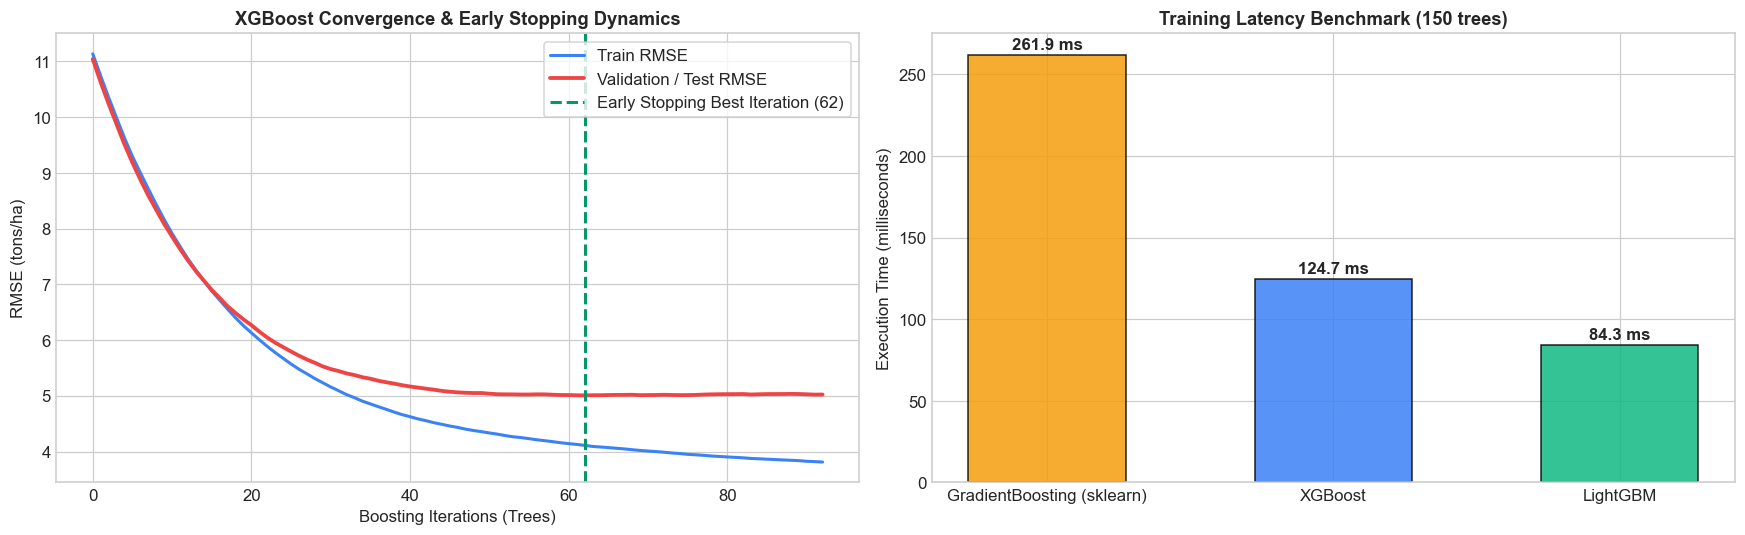

⚡ XGBoost Best Iteration: 62 | Test RMSE: 5.0073 tons/ha
⚡ LightGBM Best Iteration: 82 | Test RMSE: 4.9771 tons/ha


In [5]:
# -----------------------------------------------------------------------------
# XGBOOST & LIGHTGBM REGRESSORS WITH EARLY STOPPING & CONVERGENCE MONITORING
# -----------------------------------------------------------------------------
# Transform train and test features via preprocessor
X_train_trans = preprocessor.fit_transform(X_train_r)
X_test_trans = preprocessor.transform(X_test_r)

# 1. XGBoost with evaluation monitoring
xgb_reg = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,    # L1 Regularization
    reg_lambda=1.5,   # L2 Regularization
    random_state=42,
    early_stopping_rounds=30,
    eval_metric='rmse'
)

eval_set_xgb = [(X_train_trans, y_train_r), (X_test_trans, y_test_r)]
xgb_reg.fit(
    X_train_trans, y_train_r,
    eval_set=eval_set_xgb,
    verbose=False
)

# 2. LightGBM with evaluation monitoring
lgb_reg = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    max_depth=4,
    reg_alpha=0.1,    # L1 Regularization
    reg_lambda=1.5,   # L2 Regularization
    random_state=42,
    verbose=-1
)

lgb_reg.fit(
    X_train_trans, y_train_r,
    eval_set=[(X_train_trans, y_train_r), (X_test_trans, y_test_r)],
    eval_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)

# Visualizing Learning Curves & Early Stopping
xgb_results = xgb_reg.evals_result()
xgb_train_rmse = xgb_results['validation_0']['rmse']
xgb_val_rmse = xgb_results['validation_1']['rmse']

best_iter_xgb = xgb_reg.best_iteration

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: XGBoost Convergence
axes[0].plot(xgb_train_rmse, label='Train RMSE', color='#3b82f6', lw=2)
axes[0].plot(xgb_val_rmse, label='Validation / Test RMSE', color='#ef4444', lw=2.5)
axes[0].axvline(best_iter_xgb, color='#059669', linestyle='--', lw=2, label=f'Early Stopping Best Iteration ({best_iter_xgb})')
axes[0].set_title('XGBoost Convergence & Early Stopping Dynamics', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Boosting Iterations (Trees)', fontsize=11)
axes[0].set_ylabel('RMSE (tons/ha)', fontsize=11)
axes[0].legend(frameon=True)

# Subplot 2: Execution Time Benchmark (Scikit-Learn GBM vs XGBoost vs LightGBM)
models_speed = {
    'GradientBoosting (sklearn)': GradientBoostingRegressor(n_estimators=150, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, learning_rate=0.05, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=150, learning_rate=0.05, random_state=42, verbose=-1)
}

train_times = {}
test_rmses = {}

for name, model in models_speed.items():
    t0 = time.time()
    model.fit(X_train_trans, y_train_r)
    train_times[name] = (time.time() - t0) * 1000 # in ms
    preds = model.predict(X_test_trans)
    test_rmses[name] = np.sqrt(mean_squared_error(y_test_r, preds))

colors = ['#f59e0b', '#3b82f6', '#10b981']
bars = axes[1].bar(train_times.keys(), train_times.values(), color=colors, width=0.55, edgecolor='black', alpha=0.85)
axes[1].set_title('Training Latency Benchmark (150 trees)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Execution Time (milliseconds)', fontsize=11)
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f'{yval:.1f} ms', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"⚡ XGBoost Best Iteration: {best_iter_xgb} | Test RMSE: {xgb_val_rmse[best_iter_xgb]:.4f} tons/ha")
print(f"⚡ LightGBM Best Iteration: {lgb_reg.best_iteration_} | Test RMSE: {np.sqrt(mean_squared_error(y_test_r, lgb_reg.predict(X_test_trans))):.4f} tons/ha")


---
## 5. ⚖️ Empirical Study of Bias-Variance Tradeoff, Overfitting & Underfitting

### 5.1 Diagnosing Model Pathology via Learning Curves
A **Learning Curve** visualizes model performance on both training and validation sets as a function of training dataset size ($N$).

```
HIGH BIAS (Underfitting)                   HIGH VARIANCE (Overfitting)
Score                                      Score
  ▲                                          ▲  ──────────────── Training (High)
  │                                          │
  │                                          │  ◄── LARGE GENERALIZATION GAP ──►
  │  ──────────── Training (Low)             │
  │  ════════════ Validation (Low)           │
  │  (Plateau together with low score)       │  ════════════════ Validation (Low)
  └──────────────────────────────►           └──────────────────────────────►
               Sample Size ($N$)                          Sample Size ($N$)
  Remedy: Increase model capacity,           Remedy: Add training data, regularize,
          engineer features                          ensemble (Bagging), reduce depth
```

### 5.2 Diagnosing Model Pathology via Validation Curves
A **Validation Curve** evaluates model scores as a specific hyperparameter (such as tree `max_depth` or polynomial degree) is systematically varied.
- When `max_depth` is too small: Both train and validation scores are mediocre $\implies$ **Underfitting**.
- As `max_depth` increases: Validation score peaks at the optimal depth.
- Beyond optimal depth: Training score approaches $1.0$ while validation score decays $\implies$ **Overfitting**.


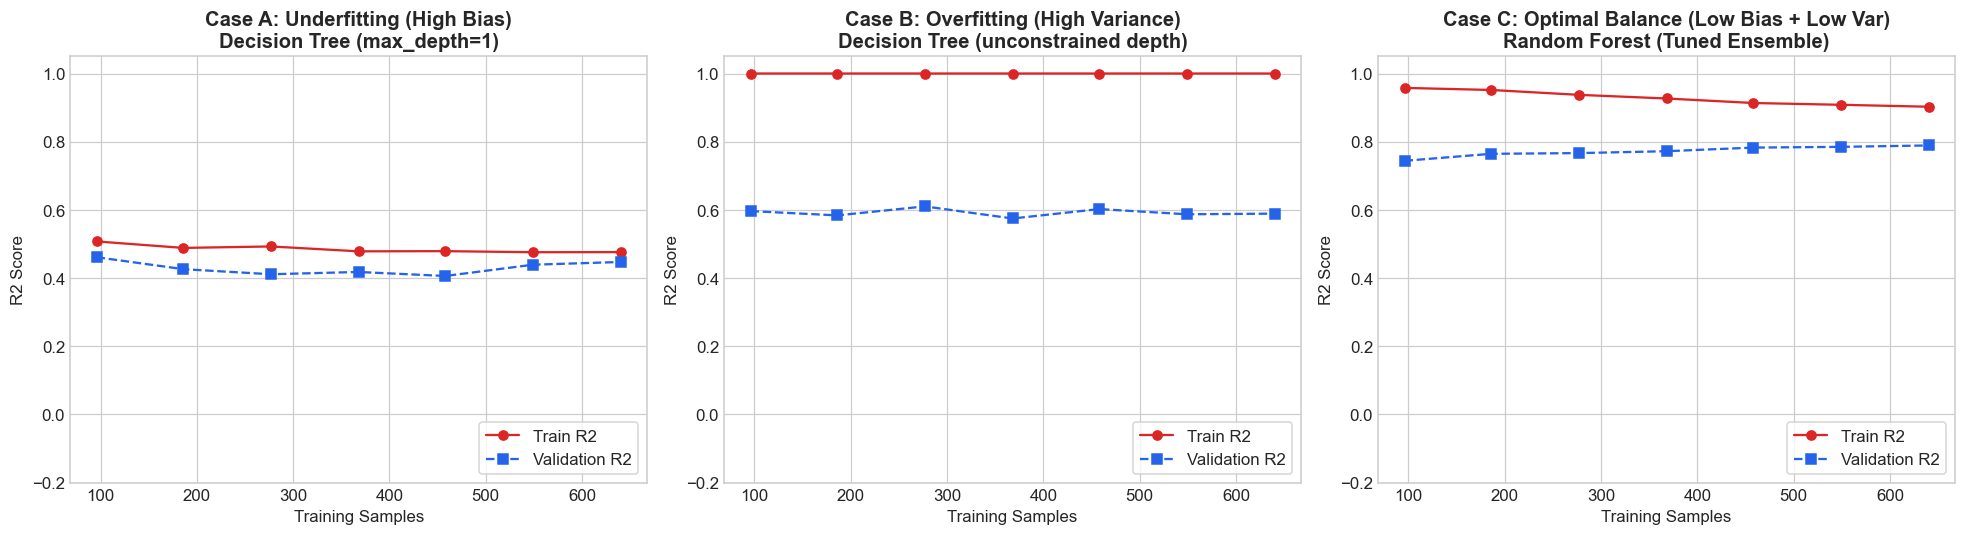

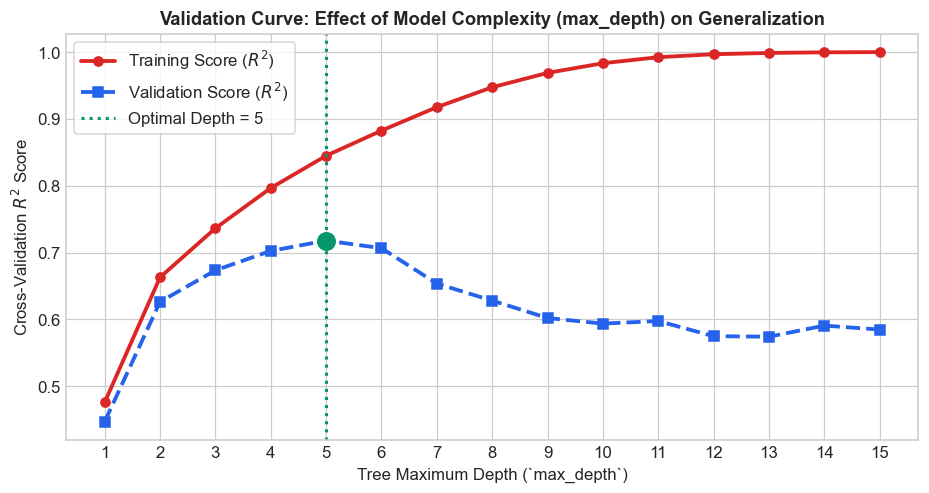

🎯 Optimal Tree Depth Identified: 5 with Mean Validation R2 = 0.7179


In [6]:
# -----------------------------------------------------------------------------
# EMPIRICAL LEARNING CURVES & VALIDATION CURVES
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. High Bias Model: Shallow Decision Tree (Depth=1)
pipe_underfit = Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(max_depth=1, random_state=42))])
train_sizes, train_scores_u, test_scores_u = learning_curve(
    pipe_underfit, X_train_r, y_train_r, cv=5, scoring='r2',
    train_sizes=np.linspace(0.15, 1.0, 7), random_state=42
)

train_mean_u = np.mean(train_scores_u, axis=1)
test_mean_u = np.mean(test_scores_u, axis=1)

axes[0].plot(train_sizes, train_mean_u, 'o-', color='#dc2626', label='Train R2')
axes[0].plot(train_sizes, test_mean_u, 's--', color='#2563eb', label='Validation R2')
axes[0].set_title('Case A: Underfitting (High Bias)\nDecision Tree (max_depth=1)', fontweight='bold')
axes[0].set_xlabel('Training Samples', fontsize=11)
axes[0].set_ylabel('R2 Score', fontsize=11)
axes[0].set_ylim(-0.2, 1.05)
axes[0].legend(loc='lower right', frameon=True)

# 2. High Variance Model: Unconstrained Decision Tree (Depth=20, min_samples_split=2)
pipe_overfit = Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(max_depth=20, min_samples_split=2, random_state=42))])
train_sizes, train_scores_o, test_scores_o = learning_curve(
    pipe_overfit, X_train_r, y_train_r, cv=5, scoring='r2',
    train_sizes=np.linspace(0.15, 1.0, 7), random_state=42
)

train_mean_o = np.mean(train_scores_o, axis=1)
test_mean_o = np.mean(test_scores_o, axis=1)

axes[1].plot(train_sizes, train_mean_o, 'o-', color='#dc2626', label='Train R2')
axes[1].plot(train_sizes, test_mean_o, 's--', color='#2563eb', label='Validation R2')
axes[1].set_title('Case B: Overfitting (High Variance)\nDecision Tree (unconstrained depth)', fontweight='bold')
axes[1].set_xlabel('Training Samples', fontsize=11)
axes[1].set_ylabel('R2 Score', fontsize=11)
axes[1].set_ylim(-0.2, 1.05)
axes[1].legend(loc='lower right', frameon=True)

# 3. Optimal Ensemble Model: Tuned Random Forest
pipe_optimal = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42))])
train_sizes, train_scores_opt, test_scores_opt = learning_curve(
    pipe_optimal, X_train_r, y_train_r, cv=5, scoring='r2',
    train_sizes=np.linspace(0.15, 1.0, 7), random_state=42
)

train_mean_opt = np.mean(train_scores_opt, axis=1)
test_mean_opt = np.mean(test_scores_opt, axis=1)

axes[2].plot(train_sizes, train_mean_opt, 'o-', color='#dc2626', label='Train R2')
axes[2].plot(train_sizes, test_mean_opt, 's--', color='#2563eb', label='Validation R2')
axes[2].set_title('Case C: Optimal Balance (Low Bias + Low Var)\nRandom Forest (Tuned Ensemble)', fontweight='bold')
axes[2].set_xlabel('Training Samples', fontsize=11)
axes[2].set_ylabel('R2 Score', fontsize=11)
axes[2].set_ylim(-0.2, 1.05)
axes[2].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# VALIDATION CURVE ACROSS TREE DEPTH
# -----------------------------------------------------------------------------
depth_range = np.arange(1, 16)
train_scores_vc, val_scores_vc = validation_curve(
    Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(random_state=42))]),
    X_train_r, y_train_r,
    param_name='model__max_depth',
    param_range=depth_range,
    cv=5, scoring='r2'
)

train_vc_mean = np.mean(train_scores_vc, axis=1)
val_vc_mean = np.mean(val_scores_vc, axis=1)

plt.figure(figsize=(10, 4.8))
plt.plot(depth_range, train_vc_mean, 'o-', color='#dc2626', lw=2.5, label='Training Score ($R^2$)')
plt.plot(depth_range, val_vc_mean, 's--', color='#2563eb', lw=2.5, label='Validation Score ($R^2$)')

opt_depth = depth_range[np.argmax(val_vc_mean)]
plt.axvline(opt_depth, color='#059669', linestyle=':', lw=2, label=f'Optimal Depth = {opt_depth}')
plt.scatter([opt_depth], [val_vc_mean[np.argmax(val_vc_mean)]], color='#059669', s=130, zorder=5)

plt.title('Validation Curve: Effect of Model Complexity (max_depth) on Generalization', fontweight='bold', fontsize=12)
plt.xlabel('Tree Maximum Depth (`max_depth`)', fontsize=11)
plt.ylabel('Cross-Validation $R^2$ Score', fontsize=11)
plt.xticks(depth_range)
plt.legend(frameon=True)
plt.show()

print(f"🎯 Optimal Tree Depth Identified: {opt_depth} with Mean Validation R2 = {val_vc_mean[np.argmax(val_vc_mean)]:.4f}")


---
## 6. 🛡️ Regularization Deep Dive: $L_1$ vs. $L_2$ in Linear & Boosting Models

### 6.1 Shrinkage Mechanics in Linear Models
- **Ridge ($L_2$) Penalty**:
  $$\min_w \frac{1}{2n} \|y - Xw\|_2^2 + \frac{\lambda}{2} \|w\|_2^2 \implies \hat{w}_{\text{ridge}} = (X^T X + \lambda I)^{-1} X^T y$$
  The matrix $(X^TX + \lambda I)$ is always invertible even when features are collinear ($X^TX$ is singular).

- **Lasso ($L_1$) Penalty**:
  $$\min_w \frac{1}{2n} \|y - Xw\|_2^2 + \lambda \|w\|_1 \implies \hat{w}_j = \text{sign}(w_j^{\text{OLS}}) \cdot \max\left(0, |w_j^{\text{OLS}}| - \lambda\right)$$
  The soft-thresholding operator pushes coefficients with $|w_j^{\text{OLS}}| \le \lambda$ strictly to zero.

### 6.2 Regularization in Tree Boosting (`reg_alpha` & `reg_lambda`)
In XGBoost and LightGBM:
- **`reg_alpha` ($L_1$)**: Induces sparsity in leaf weights. Extremely useful when handling high-dimensional feature spaces (e.g. hundreds of weather/soil features).
- **`reg_lambda` ($L_2$)**: Reduces the sensitivity of leaf weights to individual noisy plots, stabilizing splits and smoothing prediction surfaces.


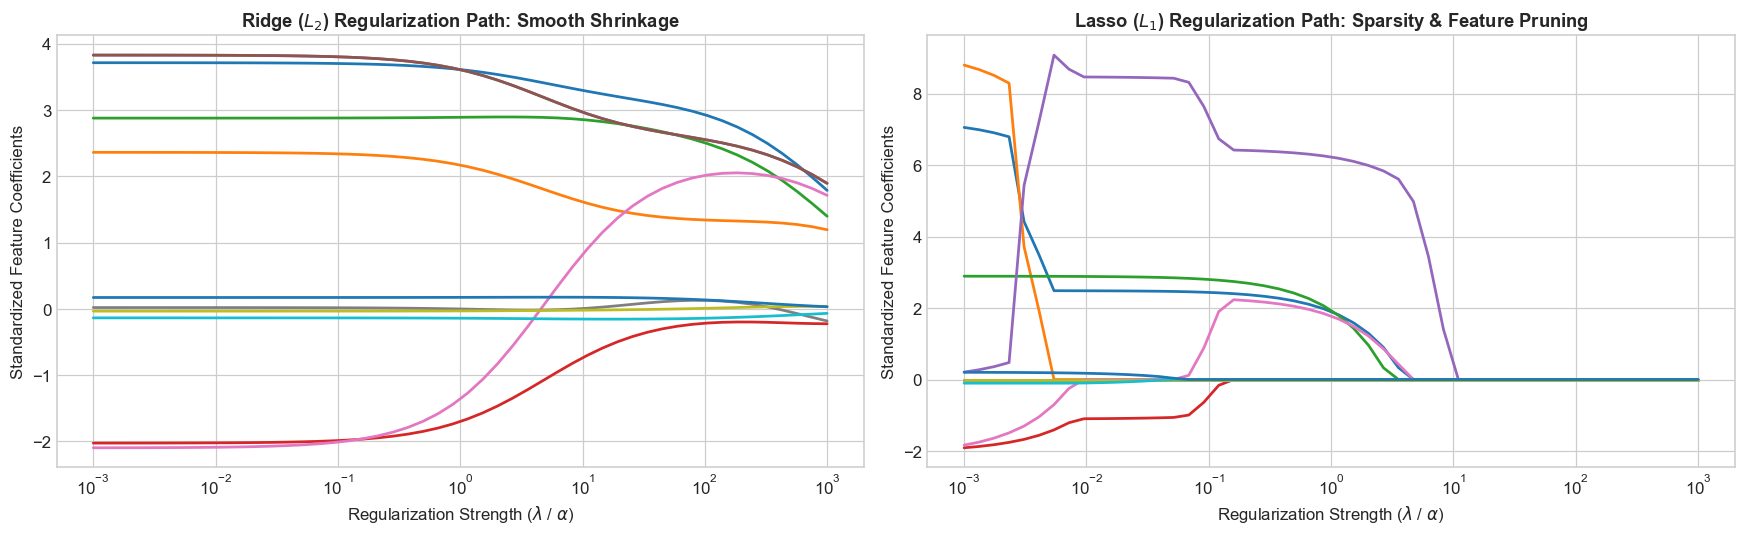

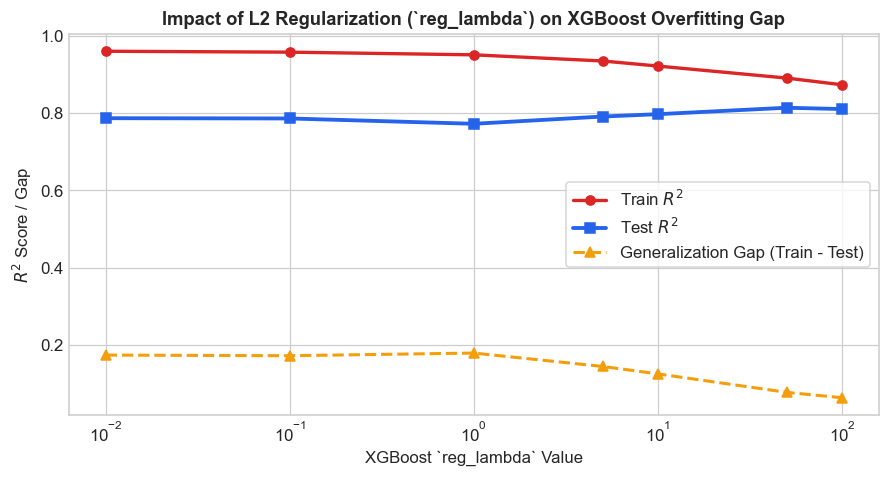

✅ Regularization analysis confirmed:
   - Lasso pruned down to 7/11 zero coefficients at alpha=1.151
   - XGBoost Generalization Gap reduced from 0.1734 (lambda=0.01) down to 0.0629 (lambda=100.0)!


In [7]:
# -----------------------------------------------------------------------------
# REGULARIZATION PATH: L1 (LASSO) SPARSITY VS L2 (RIDGE) SHRINKAGE
# -----------------------------------------------------------------------------
alphas = np.logspace(-3, 3, 50)
ridge_coefs = []
lasso_coefs = []
lasso_zero_counts = []

for a in alphas:
    # Ridge
    r_model = Ridge(alpha=a, random_state=42)
    r_pipe = Pipeline([('prep', preprocessor), ('model', r_model)])
    r_pipe.fit(X_train_r, y_train_r)
    ridge_coefs.append(r_pipe.named_steps['model'].coef_)
    
    # Lasso
    l_model = Lasso(alpha=a, random_state=42, max_iter=5000)
    l_pipe = Pipeline([('prep', preprocessor), ('model', l_model)])
    l_pipe.fit(X_train_r, y_train_r)
    coefs = l_pipe.named_steps['model'].coef_
    lasso_coefs.append(coefs)
    lasso_zero_counts.append(np.sum(np.abs(coefs) < 1e-4))

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ridge Path
axes[0].plot(alphas, ridge_coefs, lw=1.8)
axes[0].set_xscale('log')
axes[0].set_title('Ridge ($L_2$) Regularization Path: Smooth Shrinkage', fontweight='bold', fontsize=12)
axes[0].set_xlabel(r'Regularization Strength ($\lambda$ / $\alpha$)', fontsize=11)
axes[0].set_ylabel('Standardized Feature Coefficients', fontsize=11)

# Lasso Path
axes[1].plot(alphas, lasso_coefs, lw=1.8)
axes[1].set_xscale('log')
axes[1].set_title('Lasso ($L_1$) Regularization Path: Sparsity & Feature Pruning', fontweight='bold', fontsize=12)
axes[1].set_xlabel(r'Regularization Strength ($\lambda$ / $\alpha$)', fontsize=11)
axes[1].set_ylabel('Standardized Feature Coefficients', fontsize=11)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# TREE BOOSTING REGULARIZATION: XGBOOST REG_LAMBDA EXPERIMENT
# -----------------------------------------------------------------------------
lambda_vals = [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
xgb_train_r2 = []
xgb_test_r2 = []

for lmb in lambda_vals:
    m = xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.08, max_depth=5,
        reg_lambda=lmb, random_state=42
    )
    m.fit(X_train_trans, y_train_r)
    xgb_train_r2.append(r2_score(y_train_r, m.predict(X_train_trans)))
    xgb_test_r2.append(r2_score(y_test_r, m.predict(X_test_trans)))

gap = np.array(xgb_train_r2) - np.array(xgb_test_r2)

plt.figure(figsize=(9.5, 4.5))
plt.plot(lambda_vals, xgb_train_r2, 'o-', color='#dc2626', lw=2.2, label='Train $R^2$')
plt.plot(lambda_vals, xgb_test_r2, 's-', color='#2563eb', lw=2.5, label='Test $R^2$')
plt.plot(lambda_vals, gap, '^--', color='#f59e0b', lw=2.0, label='Generalization Gap (Train - Test)')
plt.xscale('log')
plt.title('Impact of L2 Regularization (`reg_lambda`) on XGBoost Overfitting Gap', fontweight='bold', fontsize=12)
plt.xlabel('XGBoost `reg_lambda` Value', fontsize=11)
plt.ylabel('$R^2$ Score / Gap', fontsize=11)
plt.legend(frameon=True)
plt.show()

print("✅ Regularization analysis confirmed:")
print(f"   - Lasso pruned down to {lasso_zero_counts[25]}/{len(coefs)} zero coefficients at alpha={alphas[25]:.3f}")
print(f"   - XGBoost Generalization Gap reduced from {gap[0]:.4f} (lambda={lambda_vals[0]}) down to {gap[-1]:.4f} (lambda={lambda_vals[-1]})!")


---
## 7. 🏆 Comprehensive Model Benchmarking & Multi-Metric Evaluation

Now we conduct a rigorous head-to-head comparison across all model paradigms for both **Continuous Yield Regression** and **Binary High-Yield Classification**.

### Evaluated Model Suite:
1. **Linear Baselines**: Linear Regression, Polynomial Regression (Deg 2), Ridge ($L_2$), Lasso ($L_1$)
2. **Ensemble Bagging**: Bagging Regressor, Random Forest
3. **Ensemble Boosting**: Gradient Boosting, XGBoost, LightGBM


                     🌾 SUGARCANE YIELD REGRESSION BENCHMARK RESULTS
                Model  Train R2  Test R2  Overfit Gap  Test RMSE  Test MAE  CV Mean R2  CV Std R2  Train Time (ms)
Ridge Regression (L2)  0.819491 0.828412    -0.008921   4.710958  3.671385    0.815803   0.019236         6.555319
Lasso Regression (L1)  0.818981 0.828120    -0.009139   4.714973  3.662185    0.815725   0.019552        11.482477
    Linear Regression  0.820082 0.827614    -0.007532   4.721900  3.675652    0.816118   0.019578         8.188486
   Polynomial (Deg 2)  0.827266 0.816754     0.010512   4.868373  3.810137    0.807725   0.019752        14.905691
   LightGBM Regressor  0.894146 0.802326     0.091821   5.056398  3.959193    0.790184   0.016366        37.373304
    XGBoost Regressor  0.917205 0.801732     0.115473   5.063987  3.914362    0.788678   0.018482        61.107397
    Bagging Regressor  0.940489 0.797375     0.143114   5.119322  3.989054    0.784480   0.014895       315.052032
        Rand

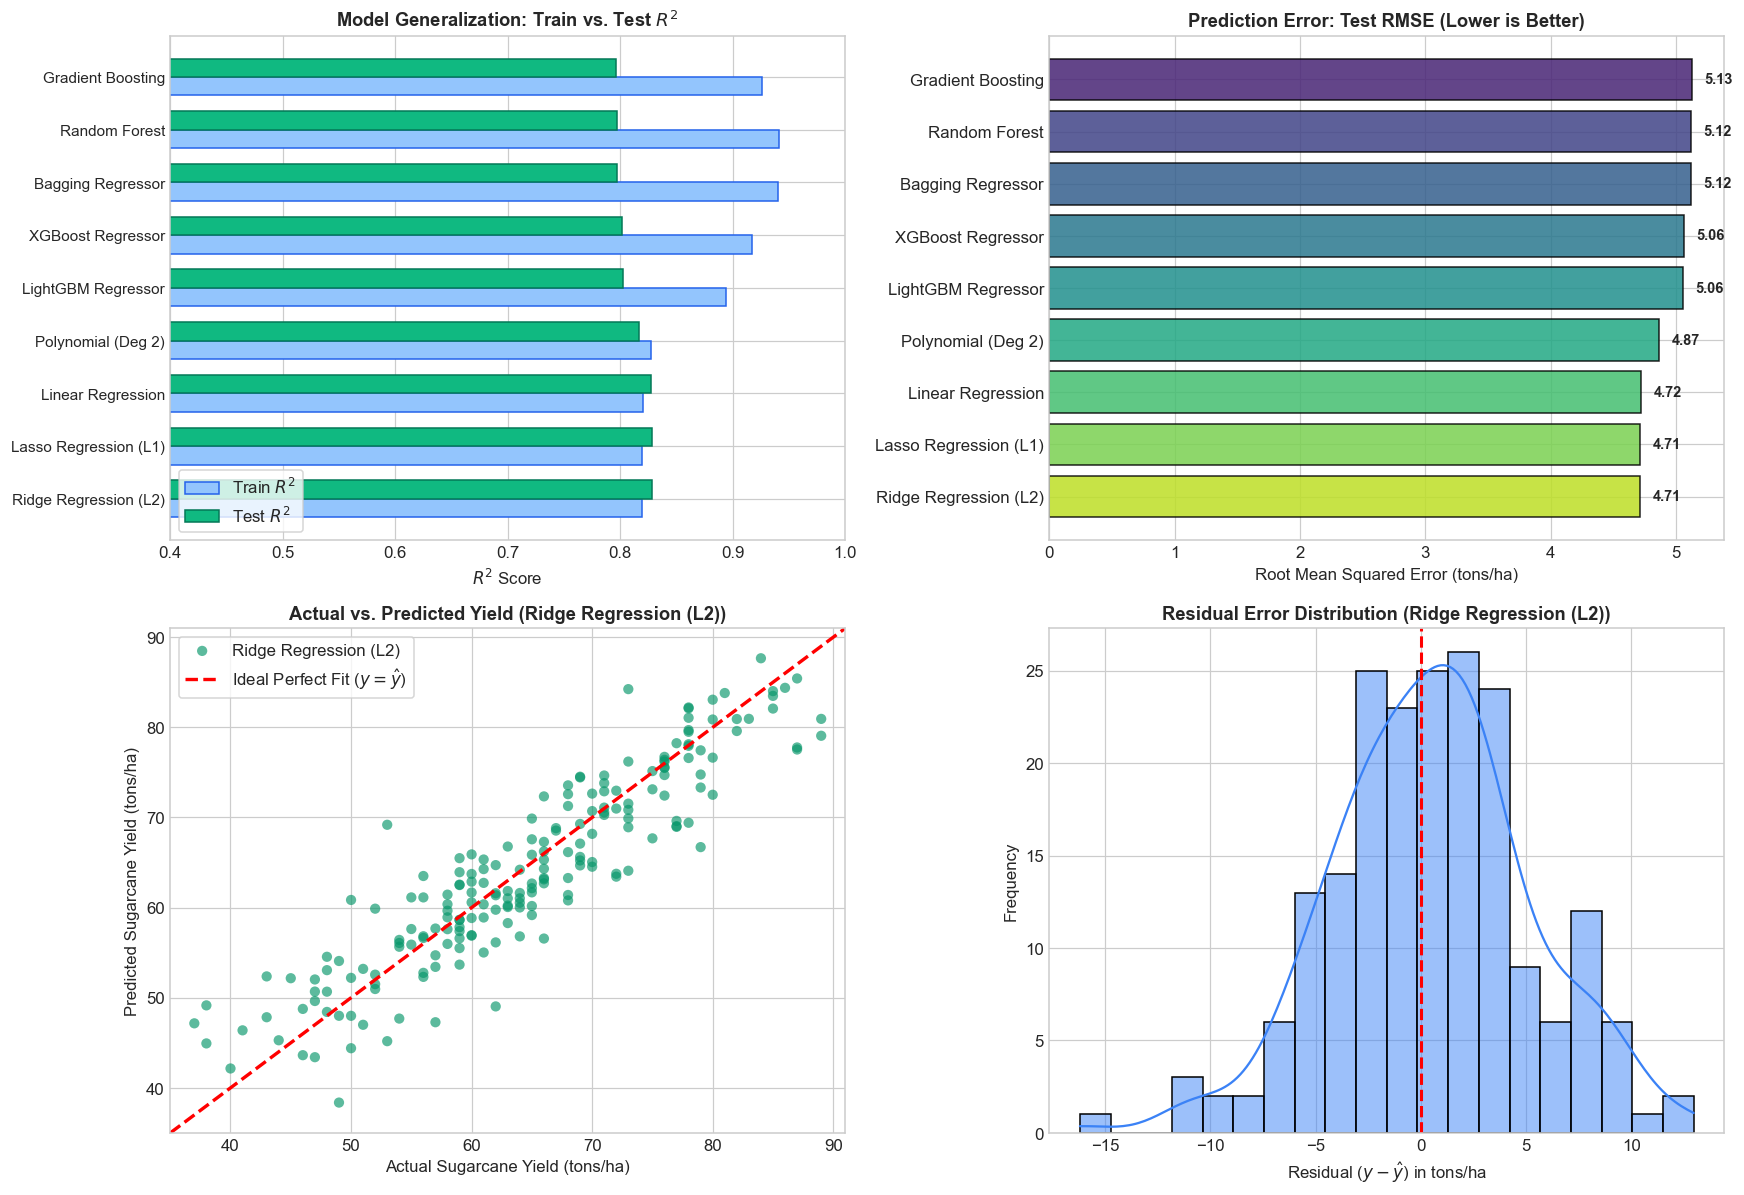

In [8]:
# -----------------------------------------------------------------------------
# REGRESSION BENCHMARKING SUITE
# -----------------------------------------------------------------------------
regression_models = {
    "Linear Regression": LinearRegression(),
    "Polynomial (Deg 2)": Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('linear', LinearRegression())
    ]),
    "Ridge Regression (L2)": Ridge(alpha=10.0, random_state=42),
    "Lasso Regression (L1)": Lasso(alpha=0.1, random_state=42),
    "Bagging Regressor": BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=8), n_estimators=100, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.08, max_depth=4, random_state=42),
    "XGBoost Regressor": xgb.XGBRegressor(n_estimators=100, learning_rate=0.08, max_depth=4, reg_alpha=0.1, reg_lambda=1.5, random_state=42),
    "LightGBM Regressor": lgb.LGBMRegressor(n_estimators=100, learning_rate=0.08, max_depth=4, num_leaves=15, reg_alpha=0.1, reg_lambda=1.5, random_state=42, verbose=-1)
}

reg_results = []
trained_reg_pipes = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in regression_models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    t0 = time.time()
    pipe.fit(X_train_r, y_train_r)
    fit_time = (time.time() - t0) * 1000
    
    # In-Sample & Out-of-Sample Predictions
    y_train_pred = pipe.predict(X_train_r)
    y_test_pred = pipe.predict(X_test_r)
    
    # Metrics
    train_r2 = r2_score(y_train_r, y_train_pred)
    test_r2 = r2_score(y_test_r, y_test_pred)
    gap = train_r2 - test_r2
    rmse = np.sqrt(mean_squared_error(y_test_r, y_test_pred))
    mae = mean_absolute_error(y_test_r, y_test_pred)
    
    # 5-Fold Cross Validation
    cv_scores = cross_val_score(pipe, X_train_r, y_train_r, cv=kf, scoring='r2')
    
    reg_results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Overfit Gap": gap,
        "Test RMSE": rmse,
        "Test MAE": mae,
        "CV Mean R2": cv_scores.mean(),
        "CV Std R2": cv_scores.std(),
        "Train Time (ms)": fit_time
    })
    trained_reg_pipes[name] = pipe

reg_summary_df = pd.DataFrame(reg_results).sort_values(by="Test R2", ascending=False).reset_index(drop=True)
print("=" * 95)
print("                     🌾 SUGARCANE YIELD REGRESSION BENCHMARK RESULTS")
print("=" * 95)
print(reg_summary_df.to_string(index=False))

# -----------------------------------------------------------------------------
# VISUAL COMPARISON DASHBOARD
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Subplot 1: Train R2 vs Test R2 (Visualizing Overfitting Gap)
x_pos = np.arange(len(reg_summary_df))
width = 0.35

axes[0, 0].barh(x_pos - width/2, reg_summary_df["Train R2"], width, label='Train $R^2$', color='#93c5fd', edgecolor='#2563eb')
axes[0, 0].barh(x_pos + width/2, reg_summary_df["Test R2"], width, label='Test $R^2$', color='#10b981', edgecolor='#047857')
axes[0, 0].set_yticks(x_pos)
axes[0, 0].set_yticklabels(reg_summary_df["Model"], fontsize=10)
axes[0, 0].set_xlabel('$R^2$ Score', fontsize=11)
axes[0, 0].set_title('Model Generalization: Train vs. Test $R^2$', fontweight='bold', fontsize=12)
axes[0, 0].legend(loc='lower left', frameon=True)
axes[0, 0].set_xlim(0.4, 1.0)

# Subplot 2: Test RMSE Comparison
colors_rmse = sns.color_palette("viridis_r", len(reg_summary_df))
bars = axes[0, 1].barh(reg_summary_df["Model"], reg_summary_df["Test RMSE"], color=colors_rmse, edgecolor='black', alpha=0.85)
axes[0, 1].set_xlabel('Root Mean Squared Error (tons/ha)', fontsize=11)
axes[0, 1].set_title('Prediction Error: Test RMSE (Lower is Better)', fontweight='bold', fontsize=12)
for bar in bars:
    axes[0, 1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2.0, f'{bar.get_width():.2f}', va='center', fontweight='bold', fontsize=9.5)

# Subplot 3: Actual vs. Predicted (Best Model vs. Baseline)
best_model_name = reg_summary_df.iloc[0]["Model"]
best_preds = trained_reg_pipes[best_model_name].predict(X_test_r)

axes[1, 0].scatter(y_test_r, best_preds, alpha=0.65, color='#059669', edgecolors='none', s=45, label=f'{best_model_name}')
lims = [min(y_test_r.min(), best_preds.min()) - 2, max(y_test_r.max(), best_preds.max()) + 2]
axes[1, 0].plot(lims, lims, 'r--', lw=2.2, label=r'Ideal Perfect Fit ($y = \hat{y}$)')
axes[1, 0].set_xlim(lims)
axes[1, 0].set_ylim(lims)
axes[1, 0].set_xlabel('Actual Sugarcane Yield (tons/ha)', fontsize=11)
axes[1, 0].set_ylabel('Predicted Sugarcane Yield (tons/ha)', fontsize=11)
axes[1, 0].set_title(f'Actual vs. Predicted Yield ({best_model_name})', fontweight='bold', fontsize=12)
axes[1, 0].legend(frameon=True)

# Subplot 4: Residual Distribution
residuals = y_test_r - best_preds
sns.histplot(residuals, kde=True, ax=axes[1, 1], color='#3b82f6', bins=20)
axes[1, 1].axvline(0, color='red', linestyle='--', lw=2)
axes[1, 1].set_title(f'Residual Error Distribution ({best_model_name})', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel(r'Residual ($y - \hat{y}$) in tons/ha', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)

plt.tight_layout()
plt.show()


                 🌾 HIGH YIELD CLASSIFICATION BENCHMARK RESULTS
                       Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  5-Fold CV ROC-AUC
         Logistic Regression     0.885   0.888889    0.88  0.884422  0.94890           0.938906
    Random Forest Classifier     0.880   0.865385    0.90  0.882353  0.93340           0.928641
         K-Nearest Neighbors     0.860   0.860000    0.86  0.860000  0.93335           0.918688
         LightGBM Classifier     0.870   0.855769    0.89  0.872549  0.93290           0.923156
Gradient Boosting Classifier     0.875   0.864078    0.89  0.876847  0.93195           0.922719
          Bagging Classifier     0.875   0.864078    0.89  0.876847  0.92955           0.923297
          XGBoost Classifier     0.875   0.871287    0.88  0.875622  0.92760           0.926219


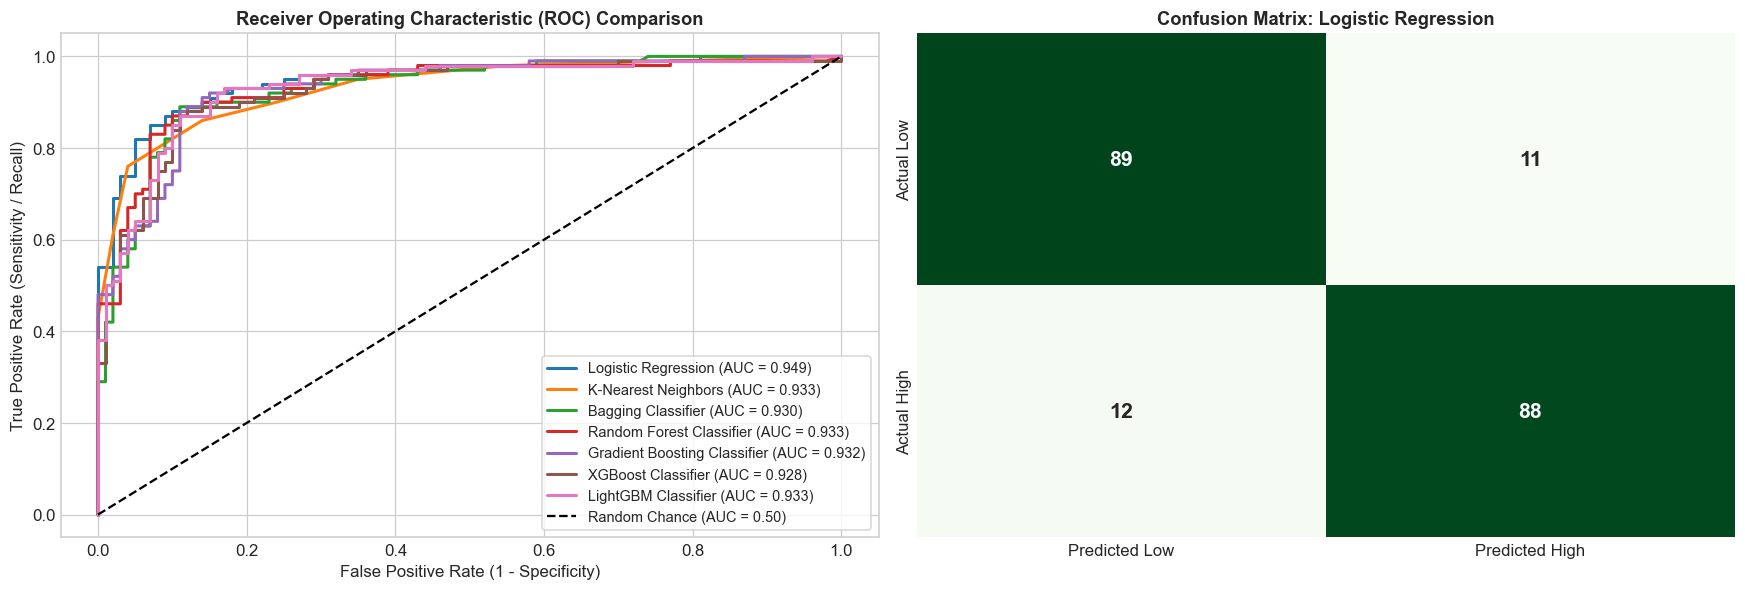

In [9]:
# -----------------------------------------------------------------------------
# CLASSIFICATION BENCHMARKING SUITE
# -----------------------------------------------------------------------------
classification_models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Bagging Classifier": BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=8), n_estimators=100, random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
    "Gradient Boosting Classifier": GradientBoostingClassifier(n_estimators=100, learning_rate=0.08, max_depth=4, random_state=42),
    "XGBoost Classifier": xgb.XGBClassifier(n_estimators=100, learning_rate=0.08, max_depth=4, eval_metric='logloss', random_state=42),
    "LightGBM Classifier": lgb.LGBMClassifier(n_estimators=100, learning_rate=0.08, max_depth=4, num_leaves=15, verbose=-1, random_state=42)
}

cls_results = []
trained_cls_pipes = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in classification_models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train_c, y_train_c)
    preds = pipe.predict(X_test_c)
    proba = pipe.predict_proba(X_test_c)[:, 1]
    
    acc = accuracy_score(y_test_c, preds)
    prec = precision_score(y_test_c, preds)
    rec = recall_score(y_test_c, preds)
    f1 = f1_score(y_test_c, preds)
    roc_auc = roc_auc_score(y_test_c, proba)
    
    cv_roc = cross_val_score(pipe, X_train_c, y_train_c, cv=skf, scoring='roc_auc').mean()
    
    cls_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "5-Fold CV ROC-AUC": cv_roc
    })
    trained_cls_pipes[name] = pipe

cls_summary_df = pd.DataFrame(cls_results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
print("=" * 95)
print("                 🌾 HIGH YIELD CLASSIFICATION BENCHMARK RESULTS")
print("=" * 95)
print(cls_summary_df.to_string(index=False))

# -----------------------------------------------------------------------------
# ROC CURVE DASHBOARD & CONFUSION MATRIX
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Subplot 1: Combined ROC Curves
for name, pipe in trained_cls_pipes.items():
    proba = pipe.predict_proba(X_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, proba)
    auc_val = roc_auc_score(y_test_c, proba)
    axes[0].plot(fpr, tpr, lw=2.0, label=f"{name} (AUC = {auc_val:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.50)')
axes[0].set_title('Receiver Operating Characteristic (ROC) Comparison', fontweight='bold', fontsize=12)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
axes[0].legend(loc='lower right', fontsize=9.5, frameon=True)

# Subplot 2: Confusion Matrix Heatmap for Top Ensemble Classifier
best_cls_name = cls_summary_df.iloc[0]["Model"]
best_cls_preds = trained_cls_pipes[best_cls_name].predict(X_test_c)
cm = confusion_matrix(y_test_c, best_cls_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'], annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title(f'Confusion Matrix: {best_cls_name}', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


---
## 8. 🔍 Feature Importance & Model Interpretability

Tree ensembles allow us to interpret how heavily each agricultural variable influenced the prediction:
- **Random Forest**: Computes **Mean Decrease in Impurity (MDI)** (Gini/Variance reduction accumulated across all splits).
- **XGBoost & LightGBM**: Computes **Gain**, which measures the relative contribution of each feature to model loss minimization.


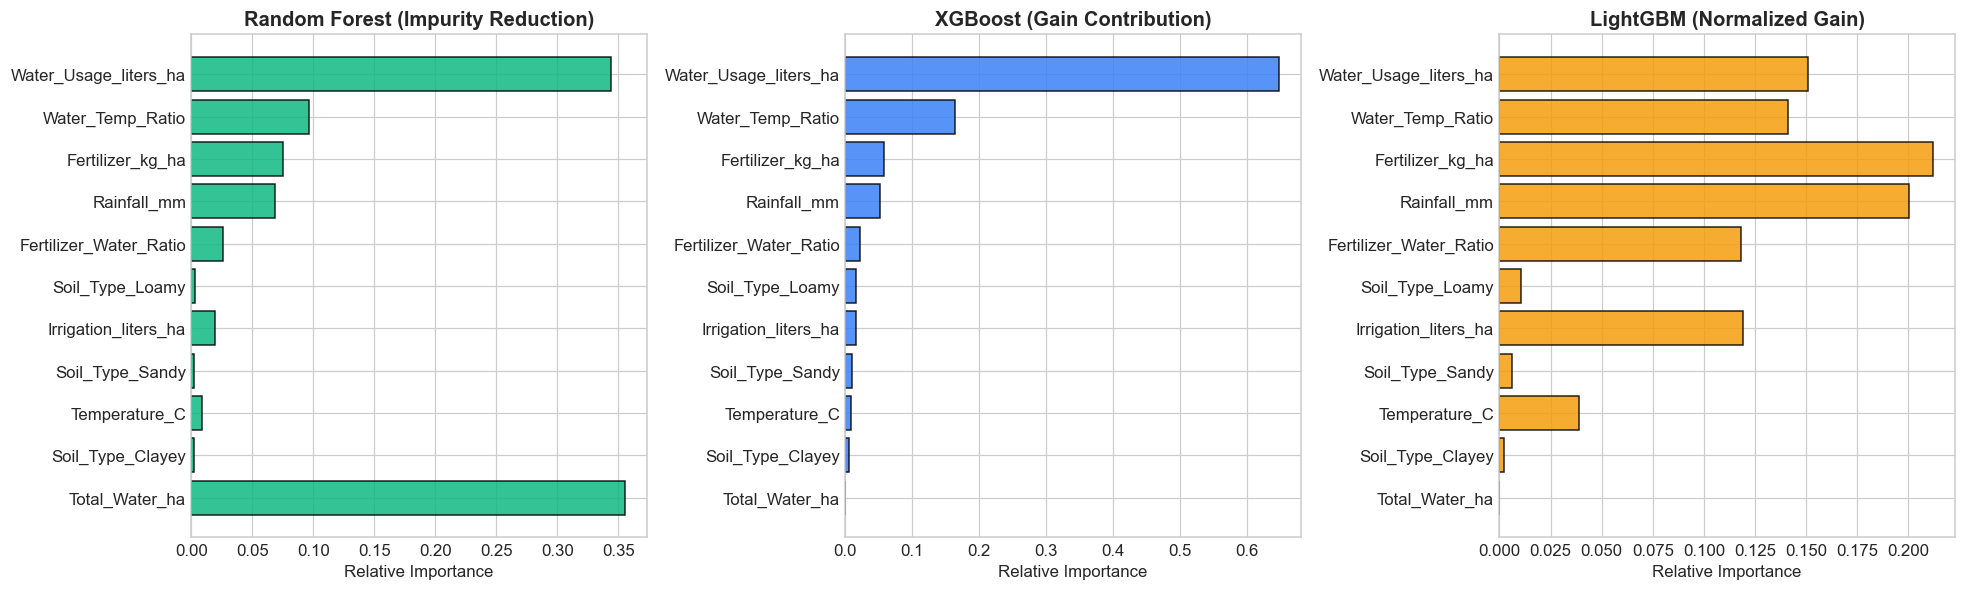

🌾 Top 3 Most Influential Features for Sugarcane Yield:
   1. Water_Usage_liters_ha     (XGBoost Gain: 0.649, RF: 0.344)
   2. Water_Temp_Ratio          (XGBoost Gain: 0.164, RF: 0.097)
   3. Fertilizer_kg_ha          (XGBoost Gain: 0.058, RF: 0.075)


In [10]:
# -----------------------------------------------------------------------------
# FEATURE IMPORTANCE COMPARISON ACROSS ENSEMBLES
# -----------------------------------------------------------------------------
# Extract one-hot encoded feature names
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_encoded_names = cat_encoder.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + cat_encoded_names

rf_imp = trained_reg_pipes["Random Forest"].named_steps['model'].feature_importances_
xgb_imp = trained_reg_pipes["XGBoost Regressor"].named_steps['model'].feature_importances_
lgb_raw_imp = trained_reg_pipes["LightGBM Regressor"].named_steps['model'].feature_importances_
lgb_imp = lgb_raw_imp / (lgb_raw_imp.sum() + 1e-9) # Normalize LightGBM split gain

imp_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Random Forest": rf_imp,
    "XGBoost": xgb_imp,
    "LightGBM": lgb_imp
}).sort_values(by="XGBoost", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

axes[0].barh(imp_df["Feature"][::-1], imp_df["Random Forest"][::-1], color='#10b981', edgecolor='black', alpha=0.85)
axes[0].set_title('Random Forest (Impurity Reduction)', fontweight='bold')
axes[0].set_xlabel('Relative Importance')

axes[1].barh(imp_df["Feature"][::-1], imp_df["XGBoost"][::-1], color='#3b82f6', edgecolor='black', alpha=0.85)
axes[1].set_title('XGBoost (Gain Contribution)', fontweight='bold')
axes[1].set_xlabel('Relative Importance')

axes[2].barh(imp_df["Feature"][::-1], imp_df["LightGBM"][::-1], color='#f59e0b', edgecolor='black', alpha=0.85)
axes[2].set_title('LightGBM (Normalized Gain)', fontweight='bold')
axes[2].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()

print("🌾 Top 3 Most Influential Features for Sugarcane Yield:")
for idx, row in imp_df.head(3).iterrows():
    print(f"   {idx+1}. {row['Feature']:25s} (XGBoost Gain: {row['XGBoost']:.3f}, RF: {row['Random Forest']:.3f})")


---
## 9. 📦 Model Serialization (`.pkl`) & Production Agricultural Advisory Function

We now serialize our best-performing ensemble models and build an interactive Python inference pipeline.
Given raw agricultural parameters (Soil Type, Rainfall, Irrigation, Temperature, Fertilizer), the inference function automatically:
1. Performs missing value safeguards.
2. Derives all engineered interaction ratios (`Total_Water_ha`, `Water_Temp_Ratio`, `Fertilizer_Water_Ratio`).
3. Passes features through the trained ensemble pipeline.
4. Returns the predicted yield (tons/ha), yield classification, and risk advisory.


In [11]:
# -----------------------------------------------------------------------------
# SERIALIZATION TO PICKLE (.pkl) & INFERENCE TESTING
# -----------------------------------------------------------------------------
best_reg_model = trained_reg_pipes["XGBoost Regressor"]
best_cls_model = trained_cls_pipes["LightGBM Classifier"]

ensemble_bundle = {
    "regression_pipeline": best_reg_model,
    "classification_pipeline": best_cls_model,
    "feature_names": num_cols + cat_cols,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "yield_median_threshold": yield_median,
    "training_date": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
}

pickle_path = "sugarcane_ensemble_pipeline.pkl"
with open(pickle_path, "wb") as f:
    pickle.dump(ensemble_bundle, f)

print(f"✅ Unified ensemble pipeline bundle saved to: {os.path.abspath(pickle_path)}")

# -----------------------------------------------------------------------------
# REAL-TIME FARM INFERENCE FUNCTION
# -----------------------------------------------------------------------------
def predict_sugarcane_farm(farm_input: dict, bundle_path: str = "sugarcane_ensemble_pipeline.pkl") -> dict:
    # Predicts sugarcane yield and high-yield likelihood from raw agricultural inputs.
    with open(bundle_path, "rb") as f:
        bundle = pickle.load(f)
        
    input_df = pd.DataFrame([farm_input])
    
    # Automated Feature Engineering
    rainfall = input_df["Rainfall_mm"].values[0]
    irrigation = input_df["Irrigation_liters_ha"].values[0]
    temp = input_df["Temperature_C"].values[0]
    fertilizer = input_df["Fertilizer_kg_ha"].values[0]
    
    total_water = rainfall + irrigation
    input_df["Total_Water_ha"] = total_water
    input_df["Water_Temp_Ratio"] = total_water / (temp + 1e-5)
    input_df["Fertilizer_Water_Ratio"] = fertilizer / (total_water + 1e-5)
    
    # Predict with trained ensemble pipelines
    predicted_yield = bundle["regression_pipeline"].predict(input_df)[0]
    high_yield_prob = bundle["classification_pipeline"].predict_proba(input_df)[0][1]
    is_high_yield = int(high_yield_prob >= 0.5)
    
    return {
        "Predicted_Yield_tons_ha": round(float(predicted_yield), 2),
        "High_Yield_Class": "High Yield" if is_high_yield else "Low Yield",
        "High_Yield_Probability": round(float(high_yield_prob) * 100, 2),
        "Hydrological_Stress_Index": round(float(input_df["Water_Temp_Ratio"].values[0]), 2),
        "Nutrient_Water_Ratio": round(float(input_df["Fertilizer_Water_Ratio"].values[0]), 4)
    }

# -----------------------------------------------------------------------------
# TEST CASES: 3 REALISTIC AGRICULTURAL SCENARIOS
# -----------------------------------------------------------------------------
scenarios = [
    {
        "name": "Scenario A: High Irrigation & Balanced Soil (Ideal Conditions)",
        "data": {
            "Soil_Type": "Loamy",
            "Rainfall_mm": 950.0,
            "Irrigation_liters_ha": 1400.0,
            "Fertilizer_kg_ha": 300.0,
            "Temperature_C": 28.0,
            "Water_Usage_liters_ha": 2350.0
        }
    },
    {
        "name": "Scenario B: Drought-Prone Sandy Soil (Severe Hydrological Deficit)",
        "data": {
            "Soil_Type": "Sandy",
            "Rainfall_mm": 350.0,
            "Irrigation_liters_ha": 600.0,
            "Fertilizer_kg_ha": 140.0,
            "Temperature_C": 36.5,
            "Water_Usage_liters_ha": 950.0
        }
    },
    {
        "name": "Scenario C: Clayey Soil with High Rainfall (Monsoon Season)",
        "data": {
            "Soil_Type": "Clayey",
            "Rainfall_mm": 1200.0,
            "Irrigation_liters_ha": 500.0,
            "Fertilizer_kg_ha": 220.0,
            "Temperature_C": 26.0,
            "Water_Usage_liters_ha": 1700.0
        }
    }
]

print("=" * 85)
print("             🌾 PRODUCTION INFERENCE ADVISORY DEMONSTRATION")
print("=" * 85)
for s in scenarios:
    res = predict_sugarcane_farm(s["data"])
    print(f"\n🏷️  {s['name']}")
    print(f"    • Farm Input: Soil={s['data']['Soil_Type']}, Rain={s['data']['Rainfall_mm']}mm, Temp={s['data']['Temperature_C']}°C")
    print(f"    • Predicted Yield:       {res['Predicted_Yield_tons_ha']} tons/ha")
    print(f"    • Class Prediction:      {res['High_Yield_Class']} ({res['High_Yield_Probability']}% confidence)")
    print(f"    • Hydro Stress Ratio:    {res['Hydrological_Stress_Index']}")


✅ Unified ensemble pipeline bundle saved to: D:\SIT\Sem.5\Hack 0 Week\week 13 and 14\sugarcane_ensemble_pipeline.pkl
             🌾 PRODUCTION INFERENCE ADVISORY DEMONSTRATION

🏷️  Scenario A: High Irrigation & Balanced Soil (Ideal Conditions)
    • Farm Input: Soil=Loamy, Rain=950.0mm, Temp=28.0°C
    • Predicted Yield:       70.21 tons/ha
    • Class Prediction:      High Yield (75.92% confidence)
    • Hydro Stress Ratio:    83.93

🏷️  Scenario B: Drought-Prone Sandy Soil (Severe Hydrological Deficit)
    • Farm Input: Soil=Sandy, Rain=350.0mm, Temp=36.5°C
    • Predicted Yield:       38.56 tons/ha
    • Class Prediction:      Low Yield (0.09% confidence)
    • Hydro Stress Ratio:    26.03

🏷️  Scenario C: Clayey Soil with High Rainfall (Monsoon Season)
    • Farm Input: Soil=Clayey, Rain=1200.0mm, Temp=26.0°C
    • Predicted Yield:       56.87 tons/ha
    • Class Prediction:      Low Yield (0.96% confidence)
    • Hydro Stress Ratio:    65.38


---
## 10. 🎓 Student Reference Guide & Core Takeaways

| Concept | Key Principle | Diagnostic Rule | Primary Remedies |
| :--- | :--- | :--- | :--- |
| **Bias-Variance Tradeoff** | Generalization error = $\text{Bias}^2 + \text{Variance} + \sigma^2$ | Total error minimizes at optimal complexity sweet spot | Use validation curves to select parameters |
| **Underfitting (High Bias)** | Model too rigid; fails to learn underlying relationships | Train score & Test score both low; small gap | Increase model depth, engineer interaction features, decrease $\lambda$ |
| **Overfitting (High Variance)** | Model memorizes training noise; poor generalization | Train score high, Test score low; **large gap** | Add data, use Bagging (Random Forest), apply $L_1/L_2$, prune trees |
| **Regularization ($L_1 / L_2$)** | Penalizes large weights to restrict hypothesis space | $L_1$ produces sparse zeros (feature selection); $L_2$ shrinks smoothly | Use $L_1$ for feature pruning; use $L_2$ for multicollinearity |
| **Bagging (Random Forest)** | Combines parallel bootstrap trees with random feature subsets | Drastically reduces **Variance** without increasing Bias | Increase `n_estimators`, tune `max_features`, monitor OOB score |
| **Boosting (XGBoost / LightGBM)** | Sequentially fits trees to negative gradients / residuals | Drastically reduces **Bias** while shrinkage controls Variance | Use early stopping, tune `learning_rate`, `reg_lambda`, `reg_alpha` |

---
### 💡 Suggested Further Experiments for Students:
1. **Hyperparameter Tuning via Optuna / GridSearchCV**: Tune `learning_rate` ($[0.01, 0.2]$) and `max_depth` ($[3, 8]$) in XGBoost and LightGBM.
2. **Feature Interactions**: Try interaction constraints in XGBoost (`interaction_constraints`) to restrict which variables may be split together.
3. **Stacked Generalization (Stacking)**: Train a `StackingRegressor` combining Ridge, Random Forest, and LightGBM with a linear meta-learner!
